# **PRAKTIKUM MODUL 0**
---
## **MATA KULIAH KECERDASAN BUATAN DAN MACHINE LEARNING 2026**

| Nama                          | NRP        |
|-------------------------------|------------|
| Putu Yudi Nandanjaya Wiraguna | 5027241080 |

#### **LATAR BELAKANG DATASET**

Arlo adalah seorang data analyst di sebuah startup layanan pemesanan makanan online. Seiring meningkatnya jumlah pengguna, perusahaan juga menerima ribuan ulasan pelanggan dalam bentuk rating, komentar, dan foto makanan. Manajemen ingin memanfaatkan data tersebut untuk memahami faktor-faktor yang memengaruhi kepuasan dan sentimen pelanggan. Dataset yang diberikan kepada Arlo bersifat multimodal, karena terdiri dari data tabular (harga, rating, ukuran porsi), data teks (ulasan pelanggan), serta data image (gambar makanan). Sebelum data dapat digunakan untuk membangun model kecerdasan buatan, diperlukan proses eksplorasi dan preprocessing yang sistematis agar data siap dimodelkan.

Sebagai bagian dari tim AI, Anda diminta untuk membantu Arlo dalam menganalisis dan mempersiapkan dataset ini melalui tahapan eksplorasi dan preprocessing yang tepat.

| Nama Kolom        | Deskripsi                                                                 |
|-------------------|--------------------------------------------------------------------------|
| review_id         | ID unik untuk setiap ulasan pelanggan.                                   |
| restaurant_name   | Nama restoran tempat makanan atau minuman dipesan.                      |
| city              | Kota lokasi restoran.                                                    |
| food_name         | Nama makanan atau minuman yang direview oleh pelanggan.                 |
| category          | Kategori makanan.                                                        |
| price             | Harga makanan dalam Rupiah.                                              |
| portion_size      | Ukuran porsi makanan yang dipesan.                                       |
| rating_overall    | Rating keseluruhan yang diberikan pelanggan terhadap pesanan.           |
| rating_taste      | Rating khusus terhadap rasa makanan.                                     |
| rating_packaging  | Rating terhadap kualitas dan kerapian kemasan makanan.                  |
| rating_delivery   | Rating terhadap kecepatan dan kualitas pengiriman.                      |
| review_text       | Ulasan tertulis dari pelanggan mengenai pengalaman mereka terhadap makanan dan layanan. |
| image_name        | Nama file gambar makanan yang berkaitan dengan ulasan.                  |
| sentiment_label   | Label sentimen dari ulasan pelanggan.                                    |

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

import cv2
import os

In [25]:
df = pd.read_csv("DatasetModul0AI2026/food-review-dataset.csv", delimiter=",")
df.head()

,review_id,restaurant_name,city,food_name,category,price,portion_size,rating_overall,rating_taste,rating_packaging,rating_delivery,review_text,image_name,sentiment_label
0,2824,Curry Kingdom,Semarang,Burger,Fast Food,22280,Small,4,4,5,4.0,"Makanannya enak banget, bakal order lagi.",img_001.jpg,positive
1,4257,Curry Kingdom,Solo,Biryani,Indian,30379,Medium,3,3,4,4.0,Tidak buruk tapi tidak spesial juga.,img_021.jpg,neutral
2,7224,Kopi Santai,Depok,Pizza,Fast Food,82357,Large,4,5,4,5.0,"Makanannya enak banget, bakal order lagi.",img_004.jpg,positive
3,6925,Sushi Mori,Yogyakarta,Donat,Dessert,46434,Small,4,3,3,3.0,Standar aja menurutku.,img_019.jpg,neutral
4,6820,Sushi Mori,Semarang,Udon,Japanese,93886,Large,3,3,4,4.0,Tidak buruk tapi tidak spesial juga.,img_007.jpg,neutral


In [3]:
print("Kolom pada dataset:")
for col in df.columns:
    print(col)

Kolom pada dataset:
review_id
restaurant_name
city
food_name
category
price
portion_size
rating_overall
rating_taste
rating_packaging
rating_delivery
review_text
image_name
sentiment_label


Dari dataset yang diberikan, terdapat beberapa fitur seperti, review_id, restaurant_name, city, food_name, category, price, portion_size, rating_overall, rating_taste, rating_packaging, rating_delivery, review_text, image_name, dan sentiment_label. Fitur-fitur tersebut akan dianalisis lebih lanjut untuk menentukan mana yang relevan dalam klasifikasi sentimen. 

### **Soal 1**
---

Perusahaan berencana membangun sistem klasifikasi sentimen berdasarkan data yang tersedia. Tentukan fitur mana saja yang relevan untuk digunakan dalam pemodelan dan jelaskan alasan pemilihannya. Identifikasi pula kolom yang berperan sebagai target variable dan jelaskan mengapa kolom tersebut tepat dijadikan target. Dalam analisis ini, pertimbangkan potensi adanya fitur yang tidak relevan atau berisiko menyebabkan data leakage.


##### **Fitur yang Relevan untuk Pemodelan**

Beberapa fitur yang dianggap relevan untuk digunakan dalam proses pemodelan klasifikasi sentimen adalah sebagai berikut:

- **price**  
  Menunjukkan harga makanan yang dipesan. Harga dapat memengaruhi persepsi pelanggan terhadap nilai makanan yang diterima sehingga dapat berpengaruh terhadap sentimen yang diberikan.

- **portion_size**  
  Menggambarkan ukuran porsi makanan yang dipesan oleh pelanggan. Ukuran porsi yang sesuai atau tidak sesuai dengan ekspektasi pelanggan dapat memengaruhi tingkat kepuasan mereka.

- **category**  
  Menunjukkan kategori atau jenis makanan yang dipesan. Jenis makanan tertentu dapat memengaruhi preferensi pelanggan dan dapat memberikan konteks tambahan terhadap ulasan yang diberikan.

- **city**  
  Menunjukkan lokasi restoran tempat makanan dipesan. Perbedaan lokasi dapat memengaruhi kualitas layanan, waktu pengiriman, maupun preferensi pelanggan di wilayah tertentu.

- **rating_overall**  
  Merupakan penilaian keseluruhan yang diberikan pelanggan terhadap pesanan mereka. Nilai ini secara langsung menggambarkan tingkat kepuasan pelanggan.

- **rating_taste**  
  Menggambarkan penilaian pelanggan terhadap rasa makanan. Rasa makanan merupakan salah satu faktor utama yang memengaruhi sentimen pelanggan.

- **rating_packaging**  
  Menunjukkan kualitas kemasan makanan yang diterima oleh pelanggan. Kemasan yang baik dapat meningkatkan pengalaman pelanggan.

- **rating_delivery**  
  Menggambarkan kualitas dan kecepatan layanan pengiriman makanan. Proses pengiriman yang cepat dan baik dapat meningkatkan kepuasan pelanggan.

- **review_text**  
  Berisi ulasan teks dari pelanggan mengenai pengalaman mereka terhadap makanan dan layanan. Fitur ini sangat penting dalam analisis sentimen karena mengandung opini langsung pelanggan.

- **image_name**  
  Merepresentasikan gambar makanan yang diunggah oleh pelanggan. Informasi visual dari gambar dapat memberikan gambaran tambahan mengenai kualitas. 

##### **Target Variable**

Kolom yang berperan sebagai **target variable** dalam dataset ini adalah **sentiment_label**. Target variable merupakan variabel yang ingin diprediksi oleh model machine learning.

Alasan kolom **sentiment_label** tepat dijadikan target adalah sebagai berikut:

- **Merepresentasikan sentimen pelanggan**  
  Kolom `sentiment_label` berisi label sentimen dari ulasan pelanggan, seperti sentimen positif, negatif, atau netral. Label ini secara langsung menggambarkan opini pelanggan terhadap makanan dan layanan yang mereka terima.

- **Sesuai dengan tujuan pemodelan**  
  Tujuan dari analisis pada dataset ini adalah membangun sistem klasifikasi sentimen yang dapat memprediksi sentimen pelanggan berdasarkan berbagai informasi yang tersedia dalam dataset.

- **Memiliki hubungan dengan fitur lain**  
  Kolom `sentiment_label` dapat diprediksi berdasarkan fitur-fitur lain seperti `rating_overall`, `rating_taste`, `rating_packaging`, `rating_delivery`, serta `review_text` yang menggambarkan pengalaman pelanggan terhadap makanan dan layanan.

In [4]:
df["sentiment_label"].value_counts()

sentiment_label
positive    1517
negative     896
neutral      587
Name: count, dtype: int64

Berdasarkan hasil eksplorasi pada kolom **sentiment_label**, terlihat bahwa dataset memiliki tiga kategori sentimen yaitu **positive**, **negative**, dan **neutral**. Jumlah data untuk masing-masing kategori adalah sebagai berikut:

- **Positive : 1517 data**
- **Negative : 896 data**
- **Neutral : 587 data**

Dari distribusi tersebut dapat diketahui bahwa mayoritas ulasan pelanggan memiliki sentimen **positif**, yang menunjukkan bahwa sebagian besar pelanggan memberikan pengalaman yang baik terhadap makanan dan layanan yang mereka terima. Sementara itu, jumlah sentimen **negatif** dan **netral** lebih sedikit dibandingkan sentimen positif.


##### **Analisis Fitur Tidak Relevan dan Potensi Data Leakage**

Dalam proses pemilihan fitur untuk pemodelan machine learning, penting untuk mempertimbangkan apakah terdapat fitur yang tidak relevan atau berpotensi menyebabkan **data leakage**. Data leakage terjadi ketika suatu fitur memberikan informasi yang terlalu langsung terhadap target sehingga model dapat mempelajari pola yang tidak realistis.

**1. Fitur yang Tidak Relevan**

Beberapa fitur pada dataset tidak memiliki hubungan langsung dengan sentimen pelanggan sehingga sebaiknya tidak digunakan dalam pemodelan, antara lain:

- **review_id**  
  Kolom ini hanya berfungsi sebagai identifier unik untuk setiap ulasan pelanggan. Nilai pada kolom ini tidak memiliki hubungan dengan kepuasan atau sentimen pelanggan sehingga tidak memberikan informasi yang berguna bagi model.

- **restaurant_name**  
  Kolom ini hanya menunjukkan nama restoran tempat makanan dipesan. Banyaknya variasi nilai pada kolom ini dapat menambah kompleksitas model tanpa memberikan kontribusi signifikan terhadap prediksi sentimen.

- **food_name**  
  Kolom ini berisi nama makanan yang direview oleh pelanggan. Karena setiap makanan memiliki nama yang unik dan sangat beragam, fitur ini cenderung tidak memberikan pola yang konsisten untuk membantu model memprediksi sentimen.

**2. Potensi Data Leakage**

Beberapa fitur dalam dataset memiliki hubungan yang sangat kuat dengan tingkat kepuasan pelanggan sehingga berpotensi menyebabkan model terlalu bergantung pada fitur tersebut.

- **rating_overall**
- **rating_taste**
- **rating_packaging**
- **rating_delivery**

Fitur-fitur tersebut merupakan penilaian langsung dari pelanggan terhadap berbagai aspek layanan dan kualitas makanan. Nilai rating yang tinggi biasanya berkorelasi dengan sentimen positif, sedangkan rating yang rendah cenderung berkaitan dengan sentimen negatif. Jika fitur ini digunakan secara langsung tanpa analisis lebih lanjut, model dapat dengan mudah menebak sentimen hanya berdasarkan nilai rating, sehingga berpotensi mengurangi kemampuan model dalam memahami pola yang lebih kompleks dari data.

Dengan mempertimbangkan fitur yang tidak relevan serta potensi data leakage, proses pemodelan dapat dilakukan dengan lebih hati-hati sehingga model yang dihasilkan mampu melakukan prediksi sentimen secara lebih akurat dan realistis.

### **Soal 2**
---
Arlo ingin memahami struktur dataset sebelum melakukan analisis lebih lanjut. Lakukan eksplorasi awal untuk mengidentifikasi jumlah data, jumlah fitur, tipe data masing-masing kolom, serta klasifikasikan setiap fitur ke dalam jenis data yang sesuai (numerik, kategorikal, teks, atau citra). Jelaskan peran umum setiap jenis fitur dalam konteks analisis sentimen.


##### **Eksplorasi Awal Dataset**
Eksplorasi awal dataset dilakukan untuk memahami struktur data sebelum proses analisis lebih lanjut. Berdasarkan hasil eksplorasi menggunakan fungsi seperti `df.shape` dan `df.dtypes`, dataset terdiri dari sejumlah data ulasan pelanggan yang memiliki berbagai jenis fitur seperti numerik, kategorikal, teks, dan citra.


##### **Jumlah Data dan Fitur**
- Dataset memiliki **3000 data ulasan pelanggan**.
- Dataset memiliki **14 fitur atau kolom** yang berisi berbagai informasi terkait makanan, restoran, ulasan pelanggan, serta label sentimen.


In [5]:
rows, columns = df.shape

print("Jumlah data:", rows)
print("Jumlah fitur:", columns)

Jumlah data: 3000
Jumlah fitur: 14


##### **Tipe Data Setiap Kolom**
Berdasarkan hasil eksplorasi tipe data, setiap kolom memiliki tipe data sebagai berikut:


In [46]:
dtype_table = pd.DataFrame(df.dtypes, columns=["Data Type"])
dtype_table

,Data Type
review_id,int64
restaurant_name,str
city,str
food_name,str
category,str
price,int64
portion_size,str
rating_overall,int64
rating_taste,int64
rating_packaging,int64


##### **Klasifikasi Jenis Fitur**

Berdasarkan tipe dan karakteristik datanya, fitur dalam dataset dapat diklasifikasikan menjadi beberapa jenis sebagai berikut:

**1. Fitur Numerik**
- price
- rating_overall
- rating_taste
- rating_packaging
- rating_delivery

**Peran dalam analisis sentimen:**  
Fitur numerik menggambarkan nilai kuantitatif yang dapat memengaruhi kepuasan pelanggan. Misalnya, rating yang tinggi biasanya berkaitan dengan pengalaman yang baik sehingga dapat berhubungan dengan sentimen positif.

**2. Fitur Kategorikal**
- restaurant_name
- city
- food_name
- category
- portion_size

**Peran dalam analisis sentimen:**  
Fitur kategorikal memberikan konteks tambahan mengenai makanan, restoran, dan lokasi. Informasi ini dapat membantu model memahami pola tertentu yang mungkin memengaruhi pengalaman pelanggan.

**3. Fitur Teks**
- review_text

**Peran dalam analisis sentimen:**  
Fitur teks merupakan sumber utama dalam analisis sentimen karena berisi opini atau pengalaman pelanggan secara langsung. Dari teks ulasan ini, model dapat mempelajari kata-kata yang menunjukkan sentimen positif, negatif, atau netral.

**4. Fitur Citra**
- image_name

**Peran dalam analisis sentimen:**  
Fitur citra merepresentasikan gambar makanan yang diunggah oleh pelanggan. Dalam pendekatan multimodal, gambar dapat memberikan informasi visual mengenai kualitas atau tampilan makanan yang mungkin memengaruhi sentimen pelanggan.

**5. Target Variable**
- sentiment_label

Kolom ini berfungsi sebagai **target variable** karena berisi label sentimen pelanggan yang akan diprediksi oleh model klasifikasi.


### **Soal 3**
---
Tentukan kolom yang akan digunakan sebagai fitur dan kolom yang berperan sebagai target dalam tugas klasifikasi sentimen. Jelaskan alasan pemilihan tersebut serta diskusikan apakah terdapat fitur yang sebaiknya tidak digunakan karena berpotensi tidak relevan atau menimbulkan data leakage.


##### **Pemilihan Fitur dan Target untuk Klasifikasi Sentimen**

Dalam tugas klasifikasi sentimen, dataset perlu dipisahkan menjadi **fitur** yang digunakan sebagai input model dan **target variable** yang akan diprediksi oleh model.

##### **Target Variable**

Kolom yang digunakan sebagai **target variable** adalah:

- **sentiment_label**

Alasan pemilihan:
- Kolom `sentiment_label` berisi label sentimen pelanggan terhadap makanan dan layanan yang mereka terima.
- Nilai pada kolom ini merepresentasikan kategori sentimen seperti **positive**, **negative**, dan **neutral**.
- Tujuan dari pemodelan machine learning pada dataset ini adalah **memprediksi sentimen pelanggan**, sehingga kolom ini tepat dijadikan sebagai target dalam tugas klasifikasi sentimen.

##### **Fitur yang Digunakan**

Beberapa kolom yang dapat digunakan sebagai fitur dalam pemodelan antara lain:

- **price**  
  Menggambarkan harga makanan yang dipesan oleh pelanggan. Harga dapat memengaruhi persepsi pelanggan terhadap nilai makanan yang mereka terima.

- **portion_size**  
  Menunjukkan ukuran porsi makanan yang dipesan. Ukuran porsi dapat memengaruhi kepuasan pelanggan.

- **category**  
  Menunjukkan kategori atau jenis makanan. Informasi ini dapat memberikan konteks tambahan terhadap pengalaman pelanggan.

- **city**  
  Menunjukkan lokasi restoran yang dapat memengaruhi kualitas layanan atau waktu pengiriman.

- **rating_overall**  
  Penilaian keseluruhan pelanggan terhadap pesanan mereka.

- **rating_taste**  
  Penilaian pelanggan terhadap rasa makanan yang diterima.

- **rating_packaging**  
  Penilaian terhadap kualitas kemasan makanan.

- **rating_delivery**  
  Penilaian terhadap kualitas dan kecepatan pengiriman makanan.

- **review_text**  
  Berisi ulasan pelanggan dalam bentuk teks yang menggambarkan pengalaman mereka terhadap makanan dan layanan. Fitur ini merupakan sumber utama informasi dalam analisis sentimen.

- **image_name**  
  Merepresentasikan gambar makanan yang diunggah oleh pelanggan. Informasi visual ini dapat digunakan dalam pendekatan multimodal apabila model memanfaatkan data citra.

##### **Fitur yang Tidak Digunakan**

Beberapa kolom sebaiknya tidak digunakan sebagai fitur karena tidak relevan atau tidak memberikan informasi yang berguna bagi model:

- **review_id**  
  Kolom ini hanya berfungsi sebagai identifier unik untuk setiap ulasan dan tidak memiliki hubungan dengan sentimen pelanggan.

- **restaurant_name**  
  Kolom ini memiliki banyak variasi nilai yang sangat spesifik sehingga dapat meningkatkan kompleksitas model tanpa memberikan kontribusi yang signifikan terhadap prediksi sentimen.

- **food_name**  
  Nama makanan juga memiliki variasi yang sangat besar dan tidak selalu memberikan informasi yang konsisten terhadap sentimen pelanggan.

##### **Potensi Data Leakage**

Beberapa fitur seperti:

- **rating_overall**
- **rating_taste**
- **rating_packaging**
- **rating_delivery**

memiliki hubungan yang sangat kuat dengan kepuasan pelanggan. Nilai rating yang tinggi biasanya berkorelasi dengan sentimen positif, sedangkan rating rendah sering berkaitan dengan sentimen negatif. Oleh karena itu, jika fitur-fitur ini digunakan tanpa analisis yang tepat, model dapat terlalu bergantung pada nilai rating untuk memprediksi sentimen. Hal ini perlu diperhatikan agar model tetap mampu mempelajari pola yang lebih umum dari data dan tidak hanya mengandalkan informasi yang terlalu langsung berkaitan dengan label sentimen.

### **Soal 4**
---
Lakukan analisis terhadap fitur numerik untuk melihat distribusi data dan mendeteksi kemungkinan adanya outlier. Jelaskan metode yang digunakan serta keputusan yang diambil terkait penanganan nilai ekstrem tersebut sebelum data digunakan dalam pemodelan.


##### **Tentukan Fitur Numerik**


In [7]:
numerical_features = [
    "price",
    "rating_overall",
    "rating_taste",
    "rating_packaging",
    "rating_delivery"
]

numerical_features

['price',
 'rating_overall',
 'rating_taste',
 'rating_packaging',
 'rating_delivery']

##### **Melihat Distribusi Data**

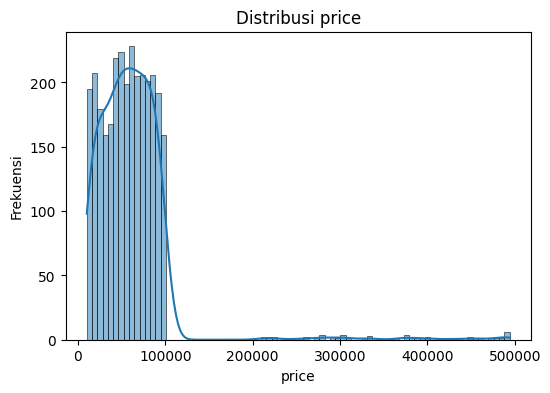

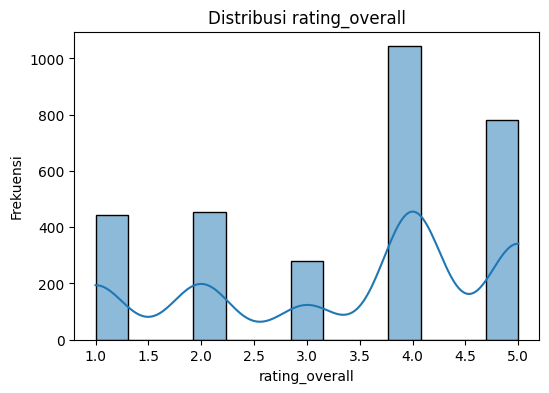

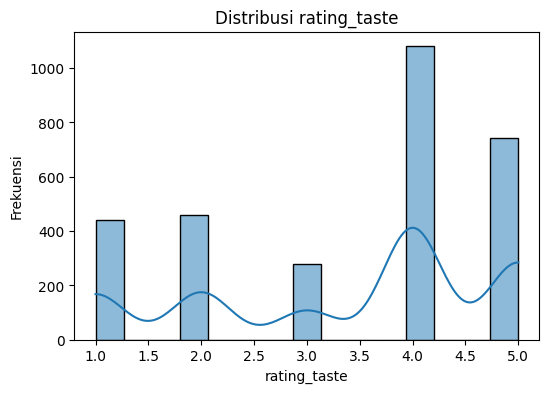

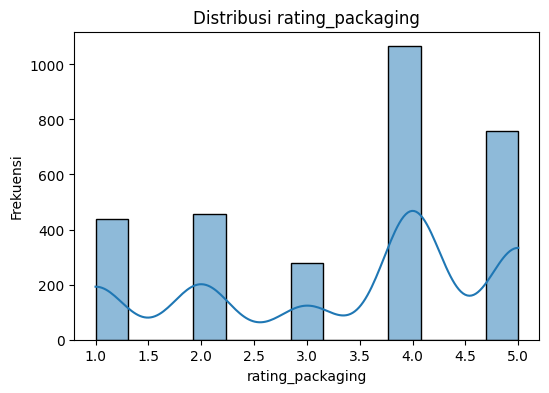

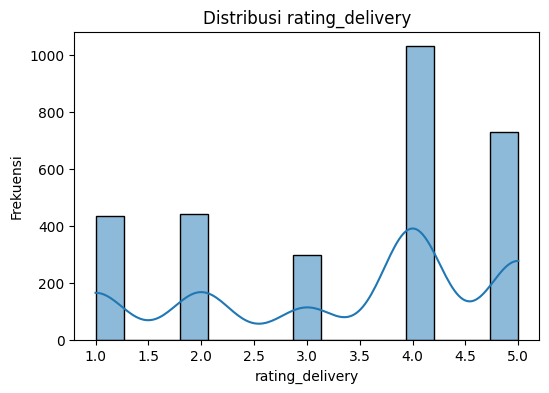

In [40]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

##### **Analisis Distribusi Fitur Numerik**

Berdasarkan visualisasi histogram, distribusi fitur numerik menunjukkan pola yang berbeda pada setiap variabel. Fitur **price** memiliki distribusi yang cenderung *right-skewed*, dimana sebagian besar harga makanan berada pada rentang sekitar 10.000 hingga 100.000, namun terdapat beberapa nilai yang jauh lebih tinggi hingga mendekati 500.000 yang mengindikasikan kemungkinan adanya nilai ekstrem.

Sementara itu, fitur **rating_overall**, **rating_taste**, **rating_packaging**, dan **rating_delivery** memiliki distribusi yang berada pada rentang nilai 1 hingga 5. Mayoritas data terkonsentrasi pada nilai **4 dan 5**, yang menunjukkan bahwa sebagian besar pelanggan memberikan penilaian yang cukup tinggi terhadap makanan dan layanan. Hal ini juga mengindikasikan bahwa ulasan pelanggan dalam dataset cenderung memiliki sentimen yang lebih positif.

##### **Mendeteksi Outlier**

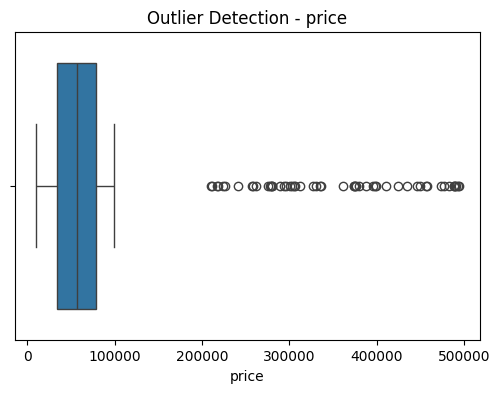

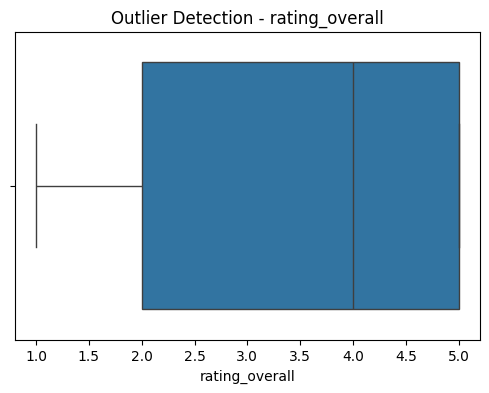

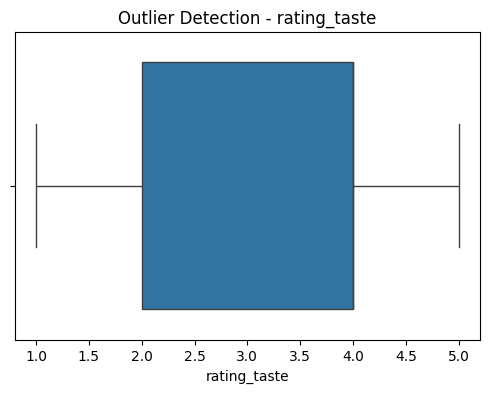

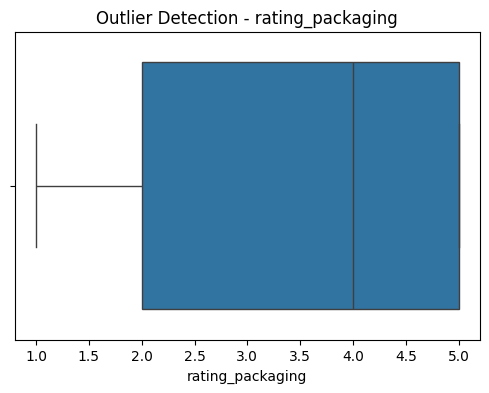

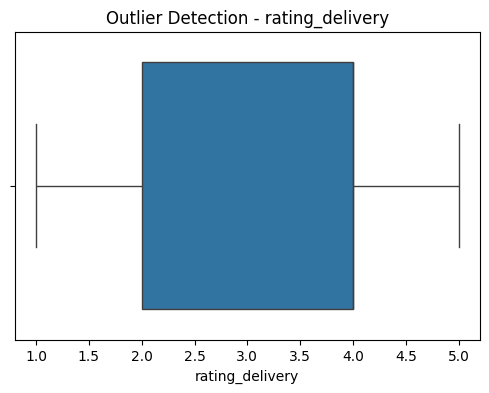

In [9]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()

In [10]:
for col in numerical_features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} memiliki {len(outliers)} outlier")

price memiliki 53 outlier
rating_overall memiliki 0 outlier
rating_taste memiliki 0 outlier
rating_packaging memiliki 0 outlier
rating_delivery memiliki 0 outlier


##### **Analisis Deteksi Outlier pada Fitur Numerik**

Untuk mendeteksi nilai ekstrem pada fitur numerik, digunakan metode **boxplot** yang didasarkan pada konsep **Interquartile Range (IQR)**. Metode ini mengidentifikasi outlier dengan melihat nilai yang berada di luar rentang distribusi utama data. Nilai dianggap sebagai outlier jika berada di luar batas:

- Lower Bound = Q1 − 1.5 × IQR  
- Upper Bound = Q3 + 1.5 × IQR  

Berdasarkan hasil visualisasi boxplot, fitur **price** menunjukkan beberapa nilai ekstrem yang berada jauh di luar distribusi utama data. Hal ini menunjukkan adanya kemungkinan outlier pada harga makanan, dimana sebagian kecil data memiliki harga yang jauh lebih tinggi dibandingkan mayoritas data.

Sementara itu, fitur **rating_overall**, **rating_taste**, **rating_packaging**, dan **rating_delivery** tidak menunjukkan adanya outlier yang signifikan karena nilai rating berada dalam rentang yang terbatas yaitu **1 hingga 5**.

Dalam tahap preprocessing sebelum pemodelan, nilai ekstrem pada fitur **price** tidak langsung dihapus karena masih mungkin merepresentasikan harga makanan yang valid. Oleh karena itu, pendekatan yang dipilih adalah melakukan **scaling atau normalisasi data** agar perbedaan nilai yang sangat besar tidak terlalu memengaruhi model machine learning. Pendekatan ini memungkinkan model tetap memanfaatkan informasi dari data tanpa menghilangkan data yang mungkin masih relevan.

### **Soal 5**
---
Lakukan preprocessing terhadap data tabular dengan mengubah fitur kategorikal menjadi format numerik serta melakukan transformasi yang diperlukan pada fitur numerik. Jelaskan metode yang digunakan dan mengapa langkah tersebut penting sebelum proses pemodelan..


##### **Tentukan Fitur Kategorikal**

In [11]:
categorical_features = [
    "city",
    "category",
    "portion_size"
]

categorical_features

['city', 'category', 'portion_size']

In [41]:

df_tabular = pd.get_dummies(df, columns=categorical_features)
df_tabular = df_tabular.drop(columns=["restaurant_name", "food_name"])

print("Data setelah encoding:")
print(df_tabular.head())

scaler = StandardScaler()

df_tabular[numerical_features] = scaler.fit_transform(
    df_tabular[numerical_features]
)

print("\nData setelah scaling fitur numerik:")
print(df_tabular[numerical_features].head())

X = df_tabular.drop(columns=[target])
y = df_tabular[target]

print("\nShape fitur (X):", X.shape)
print("Shape target (y):", y.shape)

print("\nContoh data fitur setelah preprocessing:")
print(X.head())

Data setelah encoding:
   review_id  price  rating_overall  rating_taste  rating_packaging  \
0       2824  22280               4             4                 5   
1       4257  30379               3             3                 4   
2       7224  82357               4             5                 4   
3       6925  46434               4             3                 3   
4       6820  93886               3             3                 4   

   rating_delivery                                review_text   image_name  \
0              4.0  Makanannya enak banget, bakal order lagi.  img_001.jpg   
1              4.0       Tidak buruk tapi tidak spesial juga.  img_021.jpg   
2              5.0  Makanannya enak banget, bakal order lagi.  img_004.jpg   
3              3.0                     Standar aja menurutku.  img_019.jpg   
4              4.0       Tidak buruk tapi tidak spesial juga.  img_007.jpg   

  sentiment_label                             clean_review  ...  \
0        posit

##### **Preprocessing Data Tabular**

Pada tahap preprocessing data tabular, dilakukan dua proses utama yaitu transformasi fitur kategorikal dan transformasi fitur numerik.

Fitur kategorikal seperti `city`, `category`, dan `portion_size` diubah menjadi format numerik menggunakan metode **One-Hot Encoding** dengan fungsi `pd.get_dummies()`. Metode ini mengubah setiap kategori menjadi kolom biner baru sehingga dapat diproses oleh model machine learning.

Selanjutnya, fitur numerik seperti `price`, `rating_overall`, `rating_taste`, `rating_packaging`, dan `rating_delivery` ditransformasikan menggunakan metode **StandardScaler**. Metode ini menstandarisasi nilai fitur sehingga memiliki rata-rata 0 dan standar deviasi 1.

Langkah preprocessing ini penting karena sebagian besar algoritma machine learning hanya dapat memproses data dalam bentuk numerik dan juga sensitif terhadap perbedaan skala antar fitur.

### **Soal 6**
---
Lakukan preprocessing dasar terhadap kolom ulasan teks, seperti pembersihan dan normalisasi, kemudian ubah teks menjadi representasi numerik yang dapat digunakan oleh model machine learning. Jelaskan secara singkat bagaimana proses ini membantu dalam analisis sentimen.


In [47]:
df["review_text"] = df["review_text"].fillna("")


def clean_text(text):
    text = text.lower() 
    text = re.sub(r'[^\w\s]', '', text) 
    text = re.sub(r'\d+', '', text)
    text = text.strip()  
    return text

df["clean_review"] = df["review_text"].apply(clean_text)

print("Contoh hasil cleaning teks:")
print(df[["review_text", "clean_review"]].head())

vectorizer = TfidfVectorizer(max_features=500)

X_text = vectorizer.fit_transform(df["clean_review"])

print("\nDimensi fitur teks:", X_text.shape)

print("\nContoh kata yang digunakan model:")
print(vectorizer.get_feature_names_out()[:20])

Contoh hasil cleaning teks:
                                 review_text  \
0  Makanannya enak banget, bakal order lagi.   
1       Tidak buruk tapi tidak spesial juga.   
2  Makanannya enak banget, bakal order lagi.   
3                     Standar aja menurutku.   
4       Tidak buruk tapi tidak spesial juga.   

                              clean_review  
0  makanannya enak banget bakal order lagi  
1      tidak buruk tapi tidak spesial juga  
2  makanannya enak banget bakal order lagi  
3                    standar aja menurutku  
4      tidak buruk tapi tidak spesial juga  

Dimensi fitur teks: (3000, 52)

Contoh kata yang digunakan model:
['aja' 'aneh' 'bakal' 'banget' 'berantakan' 'biasa' 'bisa' 'buruk' 'cepat'
 'cukup' 'dan' 'datangnya' 'di' 'ditingkatkan' 'ekspektasi' 'enak'
 'hambar' 'harga' 'ini' 'juara']


##### **Preprocessing Teks Ulasan**

Pada tahap preprocessing teks, dilakukan pembersihan dan normalisasi terhadap kolom `review_text`. Proses ini meliputi mengubah teks menjadi huruf kecil (lowercase), menghapus tanda baca, menghapus angka, serta menghilangkan spasi berlebih. Langkah ini bertujuan untuk membuat teks menjadi lebih konsisten sehingga memudahkan proses analisis.

Setelah proses pembersihan, teks diubah menjadi representasi numerik menggunakan metode **TF-IDF (Term Frequency – Inverse Document Frequency)**. Metode ini mengubah kata-kata dalam teks menjadi nilai numerik berdasarkan frekuensi kemunculannya dalam dokumen serta tingkat kepentingannya dalam keseluruhan dataset.

Proses ini penting karena algoritma machine learning tidak dapat memproses data teks secara langsung. Dengan mengubah teks menjadi representasi numerik, model dapat mengenali pola kata yang berkaitan dengan sentimen positif, negatif, maupun netral dalam ulasan pelanggan.

### **Soal 7**
---
Pilih beberapa sampel gambar dari dataset dan lakukan proses dasar seperti pembacaan file, resizing, serta normalisasi nilai piksel. Jelaskan bentuk data citra setelah diproses dan pentingnya tahap ini sebelum digunakan dalam model berbasis deep learning.


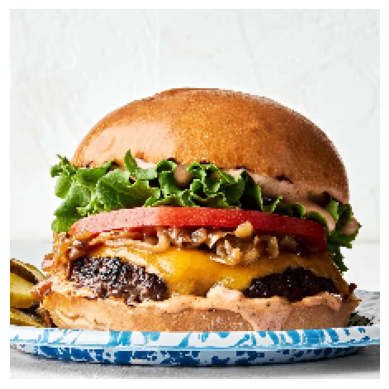

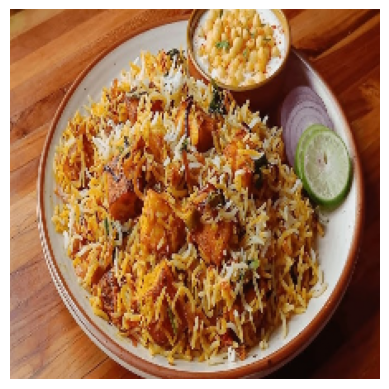

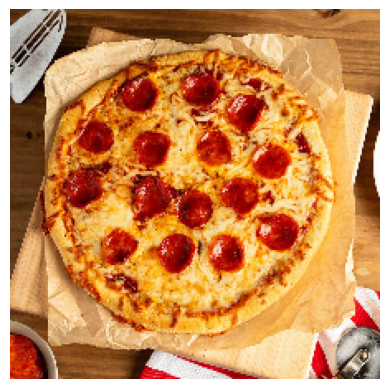

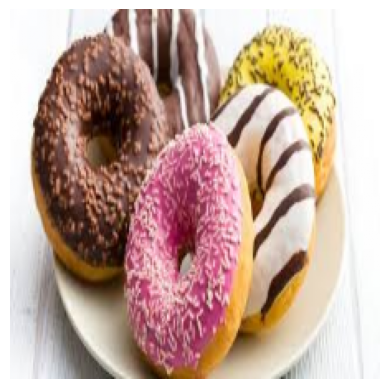

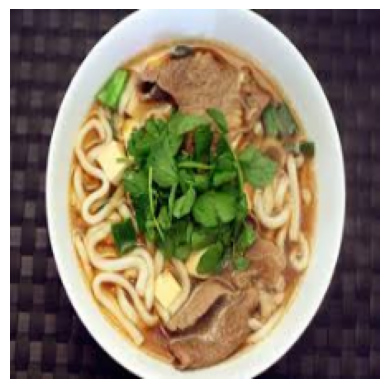

Shape data citra: (5, 224, 224, 3)


In [ ]:
image_folder = "DatasetModul0AI2026/images"
sample_images = df["image_name"].head(5)
processed_images = []

for img_name in sample_images:
    img_path = os.path.join(image_folder, img_name)
    
    img = cv2.imread(img_path)
    
    img = cv2.resize(img, (224, 224))
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img = img / 255.0
    
    processed_images.append(img)
    
    plt.imshow(img)
    plt.axis("off")
    plt.show()

processed_images = np.array(processed_images)

print("Shape data citra:", processed_images.shape)

##### **Preprocessing Data Citra**

Pada tahap ini dilakukan preprocessing dasar terhadap data citra yang terdapat pada dataset. Beberapa sampel gambar dipilih berdasarkan kolom `image_name`, kemudian dilakukan proses pembacaan file menggunakan library OpenCV.

Setelah gambar berhasil dibaca, dilakukan proses **resizing** untuk menyeragamkan ukuran gambar menjadi 224 × 224 piksel. Proses ini penting karena model deep learning umumnya membutuhkan ukuran input gambar yang konsisten.

Selanjutnya dilakukan **normalisasi nilai piksel** dengan membagi setiap nilai piksel dengan 255 sehingga nilai piksel berada pada rentang 0 hingga 1. Normalisasi ini membantu model deep learning dalam proses pembelajaran karena nilai input menjadi lebih stabil dan mudah diproses.

Setelah preprocessing, data citra direpresentasikan dalam bentuk array dengan dimensi `(jumlah_gambar, tinggi, lebar, channel_warna)`. Contohnya `(5, 224, 224, 3)` yang menunjukkan bahwa terdapat 5 gambar dengan ukuran 224 × 224 piksel dan memiliki 3 channel warna RGB.

Tahap preprocessing citra ini penting dilakukan sebelum data digunakan dalam model berbasis deep learning karena model memerlukan input berupa data numerik dengan ukuran yang konsisten dan skala nilai yang terstandarisasi.